In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
import cv2
import random
from tqdm import tqdm
from tensorflow.keras.models import load_model

In [180]:
def enhance_and_darken_strokes_updated(image_path, alpha=1.7, beta=5, kernel_size=(5, 5)):
    
    img = cv2.imread(image_path)
    if img is None:
        raise FileNotFoundError(f"Image not found at {image_path}")

    # Enhance brightness and contrast
    enhanced = cv2.convertScaleAbs(img, alpha=alpha, beta=beta)

    # Convert to grayscale
    gray = cv2.cvtColor(enhanced, cv2.COLOR_BGR2GRAY)

    # Threshold (binary inverse: white bg, black text)
    _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    # Dilate to darken/thicken strokes
    kernel = np.ones(kernel_size, np.uint8)
    dilated = cv2.dilate(thresh, kernel, iterations=1)

    # Convert back (white bg, black text)
    result = cv2.bitwise_not(dilated)

    return result


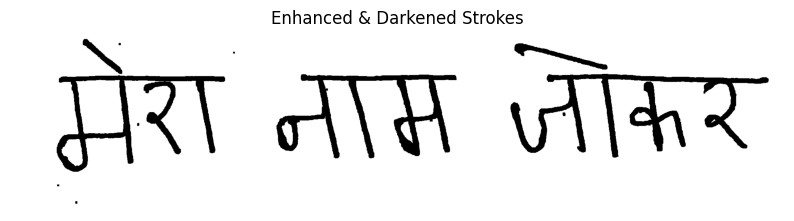

In [181]:
input_path = "F:\\ml\\plj.jpg"

# Step 1: Enhance & thicken strokes
processed_img = enhance_and_darken_strokes_updated(input_path)

# Preview intermediate result
plt.figure(figsize=(10, 6))
plt.imshow(processed_img, cmap='gray')
plt.title("Enhanced & Darkened Strokes")
plt.axis("off")
plt.show()

In [182]:
def crop_sentence_safe_margin(img, padding=10, show_steps=False):
    
    if len(img.shape) == 3:  # BGR
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    else:
        gray = img.copy()

    # Binary inverse + Otsu threshold
    _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    # Morph closing to fill gaps
    kernel = np.ones((5, 5), np.uint8)
    closed = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)

    # Find contours
    contours, _ = cv2.findContours(closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    contours = [cnt for cnt in contours if cv2.contourArea(cnt) > 100]

    if not contours:
        print("No valid contours found.")
        return img

    # Bounding box covering all contours
    all_points = np.vstack(contours)
    x, y, w, h = cv2.boundingRect(all_points)

    # Add safe margins
    x1 = max(x - padding, 0)
    y1 = max(y - padding, 0)
    x2 = min(x + w + padding, img.shape[1])
    y2 = min(y + h + padding, img.shape[0])

    cropped = img[y1:y2, x1:x2]

    if show_steps:
        boxed = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)
        cv2.rectangle(boxed, (x1, y1), (x2, y2), (0, 255, 0), 2)
        plt.figure(figsize=(12, 4))
        plt.subplot(1, 3, 1)
        plt.imshow(gray, cmap='gray')
        plt.title("Grayscale")
        plt.axis("off")
        plt.subplot(1, 3, 2)
        plt.imshow(closed, cmap='gray')
        plt.title("Closed Threshold")
        plt.axis("off")
        plt.subplot(1, 3, 3)
        plt.imshow(cv2.cvtColor(boxed, cv2.COLOR_BGR2RGB))
        plt.title("Full Sentence Box")
        plt.axis("off")
        plt.tight_layout()
        plt.show()

    return cropped


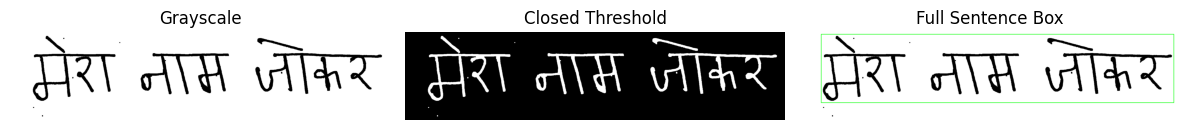

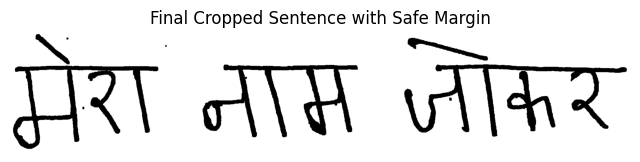

In [190]:
input_path = r"F:\ml\plj.jpg"
output_dir = r"F:\ml\plj_word"
os.makedirs(output_dir, exist_ok=True)

# Process & crop
processed_img = enhance_and_darken_strokes_updated(input_path)
cropped_img = crop_sentence_safe_margin(processed_img, padding=10, show_steps=True)

# Save final cropped image
output_path = os.path.join(output_dir, "processed.jpg")
cv2.imwrite(output_path, cropped_img)

# Final preview
plt.figure(figsize=(8, 5))
plt.imshow(cropped_img, cmap='gray')
plt.title("Final Cropped Sentence with Safe Margin")
plt.axis("off")
plt.show()

In [191]:
def segment_words_thicker_strokes(image, output_dir=None, show_steps=False):
    if len(image.shape) == 3:
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    else:
        gray = image.copy()

    # Apply slight blur to suppress noise
    blurred = cv2.GaussianBlur(gray, (3, 3), 0)

    # Adaptive thresholding for variable lighting and thin strokes
    thresh = cv2.adaptiveThreshold(
        blurred, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY_INV, 21, 15
    )

    # Dilation to connect broken lines and thin strokes more aggressively
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (40, 8))  # Wider + taller kernel
    dilated = cv2.dilate(thresh, kernel, iterations=2)  # More iterations to thicken more

    # Find contours for word-level blobs
    contours, _ = cv2.findContours(dilated, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    raw_boxes = [cv2.boundingRect(cnt) for cnt in contours if cv2.contourArea(cnt) > 100]

# Remove nested boxes
    def is_inside(inner, outer):
        xi, yi, wi, hi = inner
        xo, yo, wo, ho = outer
        return xi >= xo and yi >= yo and xi + wi <= xo + wo and yi + hi <= yo + ho

    filtered_boxes = []
    for i, box in enumerate(raw_boxes):
        if not any(i != j and is_inside(box, other) for j, other in enumerate(raw_boxes)):
            filtered_boxes.append(box)

    boxes = sorted(filtered_boxes, key=lambda b: b[0])


    word_images = []
    for i, (x, y, w, h) in enumerate(boxes):
        word_crop = image[y:y+h, x:x+w]
        word_images.append(word_crop)
        if output_dir:
            os.makedirs(output_dir, exist_ok=True)
            cv2.imwrite(os.path.join(output_dir, f"word_{i+1}.jpg"), word_crop)

    if show_steps:
        visual = image.copy()
        for (x, y, w, h) in boxes:
            cv2.rectangle(visual, (x, y), (x+w, y+h), (0, 255, 0), 2)
        plt.figure(figsize=(12, 5))
        plt.imshow(cv2.cvtColor(visual, cv2.COLOR_BGR2RGB))
        plt.title("Word Segmentation with Thicker Strokes")
        plt.axis("off")
        plt.show()

    return word_images

# # Example usage
# img_path = "/content/drive/MyDrive/devanagari+handwritten+character+dataset/processed_word/processed.jpg"
# img = cv2.imread(img_path)

# word_imgs = segment_words_thicker_strokes(img, output_dir=None, show_steps=True)
# print(f"✅ Total words extracted (strong dilation): {len(word_imgs)}")

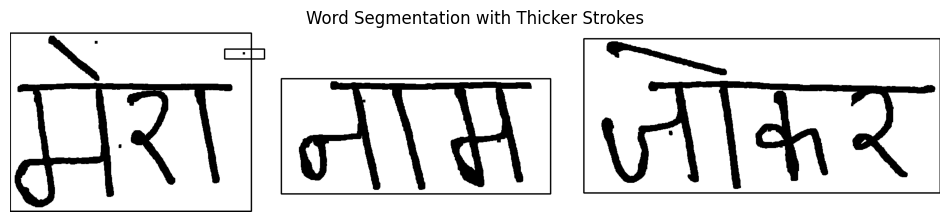

✅ Total words extracted: 4


In [193]:
input_path = r"F:\ml\plj.jpg"
output_dir = r"F:\ml\plj_word_segments"

word_imgs = segment_words_thicker_strokes(cropped_img, output_dir=output_dir, show_steps=True)

print(f"✅ Total words extracted: {len(word_imgs)}")

In [194]:
def remove_shirorekha_from_words(word_imgs=None, image_path=None, show_steps=True):

    if word_imgs is None:
        if image_path is None:
            raise ValueError("Either 'word_imgs' or 'image_path' must be provided.")
        image = cv2.imread(image_path)
        if image is None:
            raise FileNotFoundError(f"Image not found: {image_path}")
        word_imgs = segment_words_thicker_strokes(image, output_dir=None, show_steps=False)

    cleaned_words, shirorekha_positions = [], []
    print(f"🧩 Total words found: {len(word_imgs)}")

    for idx, word_img in enumerate(word_imgs):
        # Ensure grayscale
        if len(word_img.shape) == 3:
            gray = cv2.cvtColor(word_img, cv2.COLOR_BGR2GRAY)
        else:
            gray = word_img.copy()

        # Binary (white bg)
        _, binary = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)
        inv = (binary == 0).astype(np.uint8)
        h, w = inv.shape

        # Horizontal projection (sum of black pixels per row)
        h_proj = np.sum(inv, axis=1)

        # Restrict analysis to top 70% of image
        top_region = int(0.7 * h)
        h_proj_top = h_proj[:top_region]

        # Detect strong horizontal stroke region
        threshold = 0.5 * np.max(h_proj_top)
        shirorekha_rows = np.where(h_proj_top > threshold)[0]

        if len(shirorekha_rows) == 0:
            print(f"⚠️ No clear shirorekha found for word {idx+1}, skipping.")
            cleaned_words.append(binary)
            shirorekha_positions.append(None)
            continue

        # Find contiguous band of topmost dense rows
        groups = np.split(shirorekha_rows, np.where(np.diff(shirorekha_rows) > 2)[0] + 1)
        top_band = min(groups, key=lambda g: np.min(g))  # uppermost group
        shiro_top = int(np.min(top_band))
        shiro_bottom = int(np.max(top_band))

        # Remove only that top band
        result = binary.copy()
        result[shiro_top:shiro_bottom + 1, :] = 255

        cleaned_words.append(result)
        shirorekha_positions.append((shiro_top, shiro_bottom))

        # --- Visualization ---
        if show_steps:
            plt.figure(figsize=(10, 4))
            plt.subplot(1, 2, 1)
            plt.imshow(binary, cmap="gray")
            plt.title(f"Word {idx+1}: Original")
            plt.axis("off")

            plt.subplot(1, 2, 2)
            plt.imshow(result, cmap="gray")
            plt.title("After Shirorekha Removal")
            plt.axhline(y=shiro_top, color="red", linestyle="--", linewidth=1)
            plt.axhline(y=shiro_bottom, color="red", linestyle="--", linewidth=1)
            plt.axis("off")
            plt.show()

    print(f"✅ Shirorekha removed from {len(cleaned_words)} words.")
    return cleaned_words, shirorekha_positions


🧩 Total words found: 4


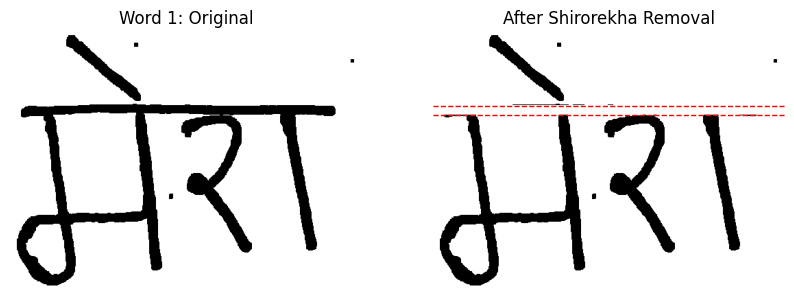

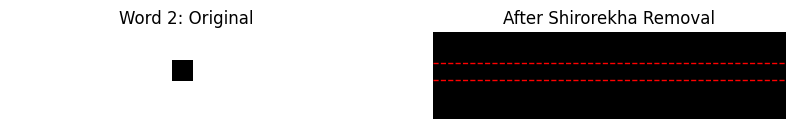

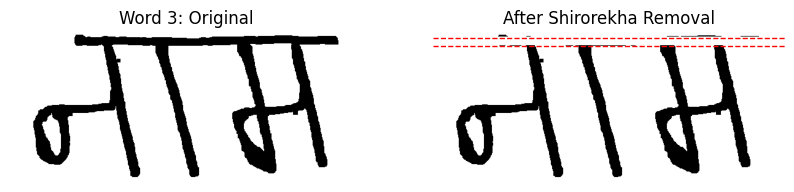

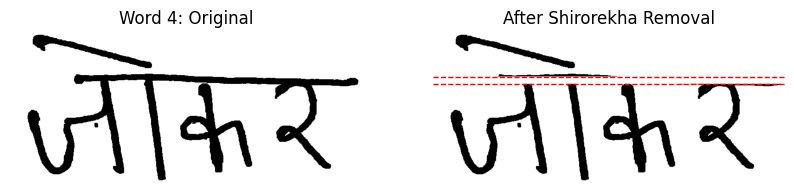

✅ Shirorekha removed from 4 words.


In [195]:
cleaned_word_imgs, shirorekha_positions = remove_shirorekha_from_words(
    word_imgs=word_imgs,
    show_steps=True
)


In [196]:
def extract_matras_after_shirorekha_removal(word_img, shirorekha_pos, debug=False):
    import cv2, numpy as np, matplotlib.pyplot as plt

    if len(word_img.shape) == 3:
        gray = cv2.cvtColor(word_img, cv2.COLOR_BGR2GRAY)
    else:
        gray = word_img.copy()

    h, w = gray.shape
    _, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    if shirorekha_pos is None:
        shiro_top, shiro_bottom = int(0.2 * h), int(0.25 * h)
    else:
        shiro_top, shiro_bottom = shirorekha_pos

    # Define matra zone above shirorekha
    matra_y_top = max(0, shiro_top - int(0.3 * h))
    matra_y_bottom = max(0, shiro_top - 2)
    matra_zone = binary[matra_y_top:matra_y_bottom, :]

    # Morphological cleanup
    close_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 3))
    dilate_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 2))
    matra_zone_closed = cv2.morphologyEx(matra_zone, cv2.MORPH_CLOSE, close_kernel, iterations=1)
    matra_zone_closed = cv2.dilate(matra_zone_closed, dilate_kernel, iterations=1)

    contours, _ = cv2.findContours(matra_zone_closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    raw_boxes = []

    for cnt in contours:
        x, y, bw, bh = cv2.boundingRect(cnt)
        area = bw * bh

        # 1️⃣ Remove ALL small boxes (no exceptions)
        if area < 80:
            continue

        y_global = y + matra_y_top
        distance_from_shirorekha = shiro_top - (y_global + bh)

        aspect_ratio = bw / (bh + 1e-5)

        # 2️⃣ Remove shirorekha residue (thin + horizontal + close)
        if (
            bh <= 4 and                # very thin
            aspect_ratio > 6 and       # horizontal
            distance_from_shirorekha <= 5
        ):
            continue

        raw_boxes.append((x, y_global, bw, bh))


    # Sort left to right
    raw_boxes = sorted(raw_boxes, key=lambda b: b[0])

    # Merge overlapping boxes
    merged = []
    merge_gap = max(6, int(0.04 * w))
    if raw_boxes:
        cur = list(raw_boxes[0])
        for (x, y, bw, bh) in raw_boxes[1:]:
            gap = x - (cur[0] + cur[2])
            if gap <= merge_gap:
                nx = min(cur[0], x)
                ny = min(cur[1], y)
                nx2 = max(cur[0] + cur[2], x + bw)
                ny2 = max(cur[1] + cur[3], y + bh)
                cur = [nx, ny, nx2 - nx, ny2 - ny]
            else:
                merged.append(tuple(cur))
                cur = [x, y, bw, bh]
        merged.append(tuple(cur))

    # Expand slightly for clarity and compute center X
    pad_x = max(2, int(0.02 * w))
    pad_y = max(2, int(0.02 * h))
    expanded_boxes = []
    for (x, y, bw, bh) in merged:
        x_new = max(0, x - pad_x)
        y_new = max(0, y - pad_y)
        w_new = min(w - x_new, bw + 2 * pad_x)
        h_new = min(h - y_new, bh + 2 * pad_y)
        x_center = x_new + w_new // 2
        expanded_boxes.append((x_new, y_new, w_new, h_new, x_center))

    # Debug visualization
    if debug:
        vis = cv2.cvtColor(255 - binary, cv2.COLOR_GRAY2BGR)
        for (x, y, bw, bh, _) in expanded_boxes:
            cv2.rectangle(vis, (x, y), (x + bw, y + bh), (0, 255, 0), 2)
        plt.figure(figsize=(10, 5))
        plt.imshow(vis)
        plt.title("Matra Detection (Filtered & Expanded Boxes)")
        plt.axis("off")
        plt.show()

    return expanded_boxes

🧩 Total words found: 4
✅ Shirorekha removed from 4 words.

🧩 Word 1: extracting matras using shirorekha position (108, 121)


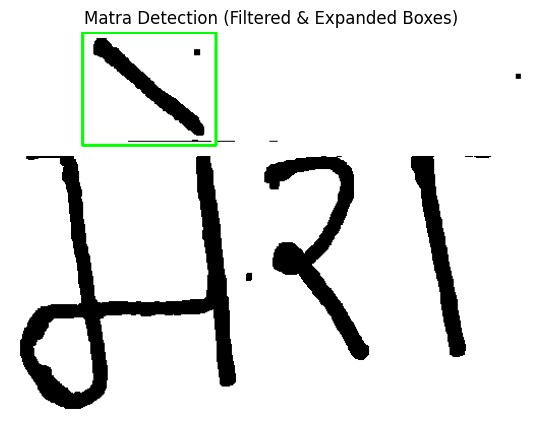

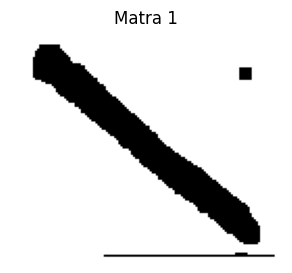


🧩 Word 2: extracting matras using shirorekha position (7, 11)


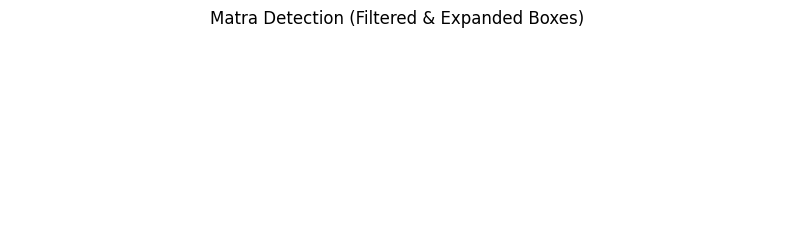


🧩 Word 3: extracting matras using shirorekha position (9, 22)


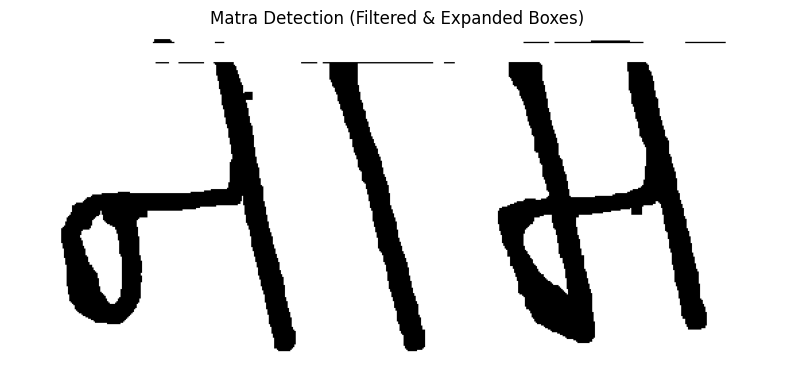


🧩 Word 4: extracting matras using shirorekha position (96, 111)


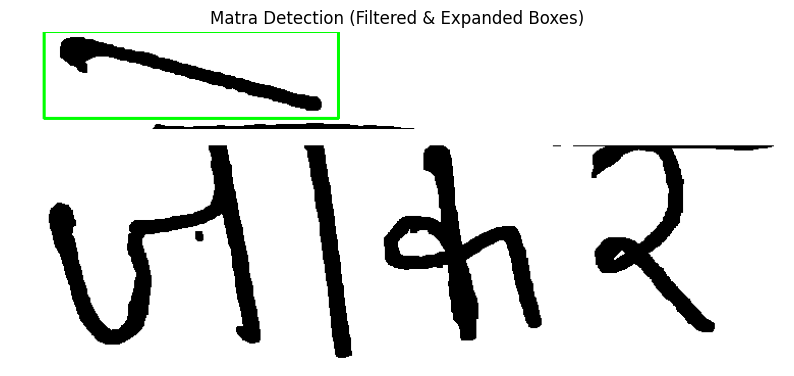

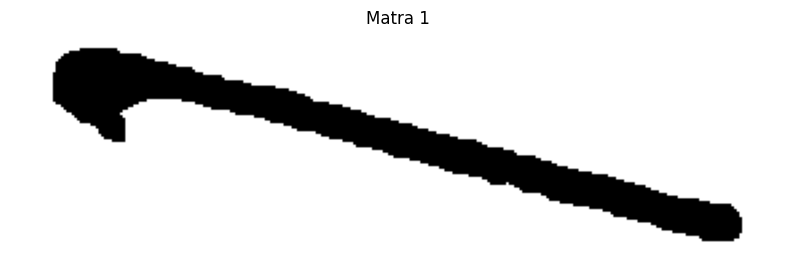

In [197]:
# Step 1 + 2: Word segmentation + Shirorekha removal
cleaned_words, shirorekha_positions = remove_shirorekha_from_words(word_imgs=word_imgs, show_steps=False)


# Step 3: Matra extraction for each cleaned word
for i, (word_img, shiro_pos) in enumerate(zip(cleaned_words, shirorekha_positions)):
    print(f"\n🧩 Word {i+1}: extracting matras using shirorekha position {shiro_pos}")
    matra_boxes = extract_matras_after_shirorekha_removal(word_img, shiro_pos, debug=True)

    matras = [word_img[y:y+h, x:x+w] for (x, y, w, h, *_) in matra_boxes]
    if len(matras) > 0:
        plt.figure(figsize=(10, 3))
        for j, m in enumerate(matras):
            plt.subplot(1, len(matras), j+1)
            plt.imshow(m, cmap='gray')
            plt.title(f"Matra {j+1}")
            plt.axis("off")
        plt.show()

In [198]:
def prepare_matra_for_model(crop, target_size=(64, 64)):
    """
    crop: numpy array of the extracted matra (binary)
    Returns: preprocessed image ready for model (1, 64, 64, 1)
    """
    # Ensure grayscale
    if len(crop.shape) == 3:
        gray = cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY)
    else:
        gray = crop.copy()

    # Invert -> black background, white foreground
    inverted = cv2.bitwise_not(gray)

    # Resize to model input size
    resized = cv2.resize(inverted, target_size, interpolation=cv2.INTER_AREA)

    # Normalize to [0,1]
    norm = resized.astype("float32") / 255.0

    # Add channel and batch dimensions
    norm = np.expand_dims(norm, axis=(0, -1))

    return norm


In [199]:
import joblib
from tensorflow.keras.models import load_model

# Load trained matra CNN
matra_model = load_model("matras.keras")

# Load label encoder
matra_le = joblib.load("matra_label_encoder.pkl")

print("✅ Matra model loaded")
print("Classes:", matra_le.classes_)


✅ Matra model loaded
Classes: ['MATRA_AI' 'MATRA_E' 'REPHA']


In [200]:
RENDER_MAP_MATRA = {
    "MATRA_E": "े",
    "MATRA_AI": "ै",
    "REPHA": "र्"
}


In [201]:
def predict_single_matra(crop, bbox, conf_threshold=0.75):
    """
    crop: extracted matra image (numpy array)
    bbox: (x, y, w, h, x_center)
    Returns: dict with prediction info or None if rejected
    """
    # Preprocess
    inp = prepare_matra_for_model(crop)

    # Predict
    probs = matra_model.predict(inp, verbose=0)[0]
    idx = np.argmax(probs)
    conf = probs[idx]

    if conf < conf_threshold:
        return None  # reject weak matra

    cls = matra_le.inverse_transform([idx])[0]

    return {
        "class_id": cls,                      # MATRA_E / MATRA_AI / REPHA
        "char": RENDER_MAP_MATRA[cls],        # े / ै / र्
        "confidence": float(conf),
        "bbox": bbox                          # (x, y, w, h, x_center)
    }


In [202]:
def predict_matras_for_word(word_img, shiro_pos, debug=False):
    """
    word_img: cleaned word image (after shirorekha removal)
    shiro_pos: (shiro_top, shiro_bottom)
    Returns: list of predicted matra dicts
    """
    matra_boxes = extract_matras_after_shirorekha_removal(
        word_img, shiro_pos, debug=debug
    )

    predictions = []

    for (x, y, w, h, x_center) in matra_boxes:
        crop = word_img[y:y+h, x:x+w]

        pred = predict_single_matra(
            crop,
            bbox=(x, y, w, h, x_center)
        )

        if pred is not None:
            predictions.append(pred)

    return predictions



🧩 Word 1


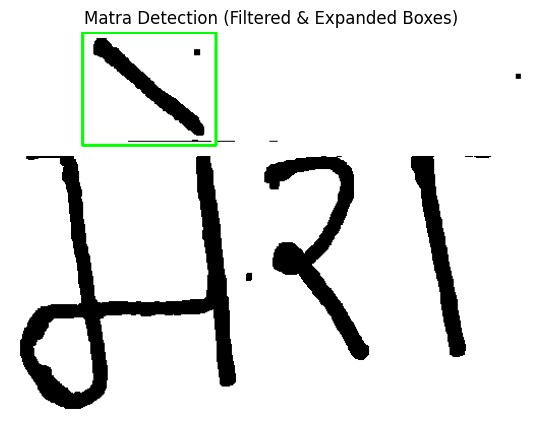

  Matra: े | Class: MATRA_E | Conf: 1.0000 | x_center: 136

🧩 Word 2


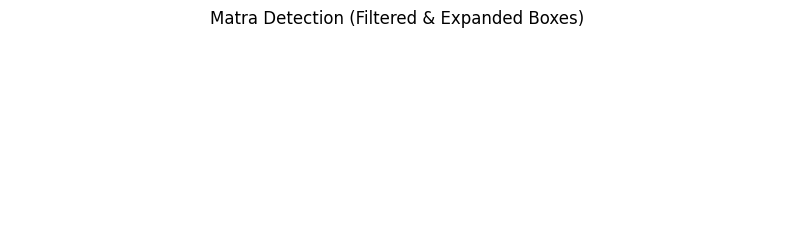

  No matras detected

🧩 Word 3


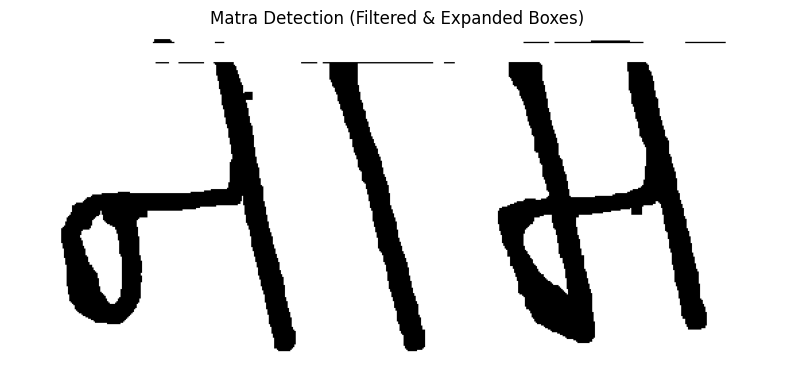

  No matras detected

🧩 Word 4


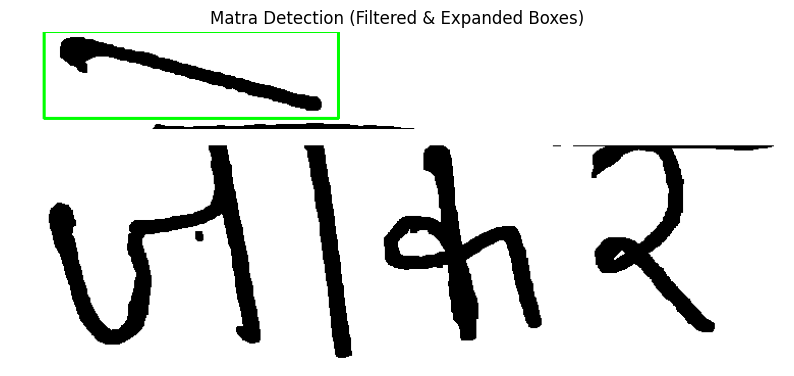

  Matra: े | Class: MATRA_E | Conf: 0.9964 | x_center: 177


In [227]:
for i, (word_img, shiro_pos) in enumerate(zip(cleaned_words, shirorekha_positions)):
    print(f"\n🧩 Word {i+1}")

    matra_preds = predict_matras_for_word(
        word_img,
        shiro_pos,
        debug=True
    )

    if not matra_preds:
        print("  No matras detected")
        continue

    for m in matra_preds:
        print(
            f"  Matra: {m['char']} | "
            f"Class: {m['class_id']} | "
            f"Conf: {m['confidence']:.4f} | "
            f"x_center: {m['bbox'][4]}"
        )


In [204]:
def segment_characters_below_shirorekha(word_img, shirorekha_y_range=None, show_steps=False):
    gray = cv2.cvtColor(word_img, cv2.COLOR_BGR2GRAY) if len(word_img.shape) == 3 else word_img
    _, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    h, w = binary.shape

    if shirorekha_y_range is not None:
        shiro_top, shiro_bottom = shirorekha_y_range
        shirorekha_y = shiro_bottom
    else:
        h_proj = np.sum(binary > 0, axis=1)
        threshold = 0.5 * np.max(h_proj)
        shirorekha_rows = np.where(h_proj > threshold)[0]
        shirorekha_y = int(np.median(shirorekha_rows)) if len(shirorekha_rows) > 0 else int(0.25 * h)

    mask = np.zeros_like(binary)
    cutoff_y = min(h, shirorekha_y + 3)
    mask[cutoff_y:, :] = 255
    chars_zone = cv2.bitwise_and(binary, mask)

    contours, _ = cv2.findContours(chars_zone, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    # boxes = [cv2.boundingRect(cnt) for cnt in contours if cv2.contourArea(cnt) > 80]
    # boxes = sorted(boxes, key=lambda b: b[0])

    # Initial bounding boxes
    boxes = [cv2.boundingRect(cnt) for cnt in contours if cv2.contourArea(cnt) > 80]
    boxes = sorted(boxes, key=lambda b: b[0])  # left-to-right

    # --- Merge overlapping or touching boxes ---
    merged_boxes = []
    for box in boxes:
        x, y, w_box, h_box = box
        if not merged_boxes:
            merged_boxes.append(box)
        else:
            prev_x, prev_y, prev_w, prev_h = merged_boxes[-1]

            # If horizontally overlapping or very close, merge into single bounding box
            if x <= prev_x + prev_w + 5:  # +5 pixels tolerance
                new_x = min(prev_x, x)
                new_y = min(prev_y, y)
                new_w = max(prev_x + prev_w, x + w_box) - new_x
                new_h = max(prev_y + prev_h, y + h_box) - new_y
                merged_boxes[-1] = (new_x, new_y, new_w, new_h)
            else:
                merged_boxes.append(box)

    boxes = merged_boxes


    character_images = []
    char_boxes_with_x = []
    for (x, y, w_box, h_box) in boxes:
        roi = word_img[y:y+h_box, x:x+w_box]
        character_images.append(roi)
        char_boxes_with_x.append((x, y, w_box, h_box, x))  # store x-axis separately

    if show_steps:
        visual = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)
        cv2.line(visual, (0, cutoff_y), (w, cutoff_y), (255, 0, 0), 1)
        for (x, y, w_box, h_box, _) in char_boxes_with_x:
            cv2.rectangle(visual, (x, y), (x+w_box, y+h_box), (0, 255, 0), 2)
        plt.figure(figsize=(10, 4))
        plt.imshow(cv2.cvtColor(visual, cv2.COLOR_BGR2RGB))
        plt.title("Character Segmentation (Below Shirorekha)")
        plt.axis("off")
        plt.show()

    return character_images, shirorekha_y, char_boxes_with_x


🧩 Total words found: 4
✅ Shirorekha removed from 4 words.

🔠 Characters (below shirorekha) in word 1:


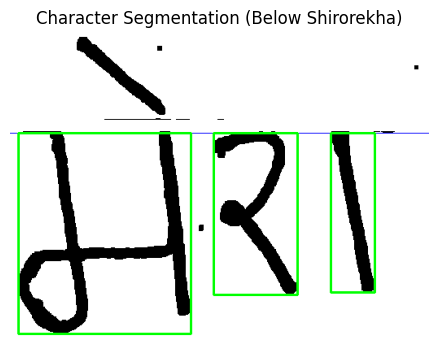


🔠 Characters (below shirorekha) in word 2:


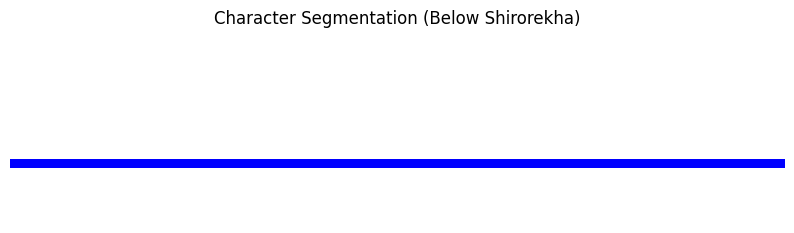


🔠 Characters (below shirorekha) in word 3:


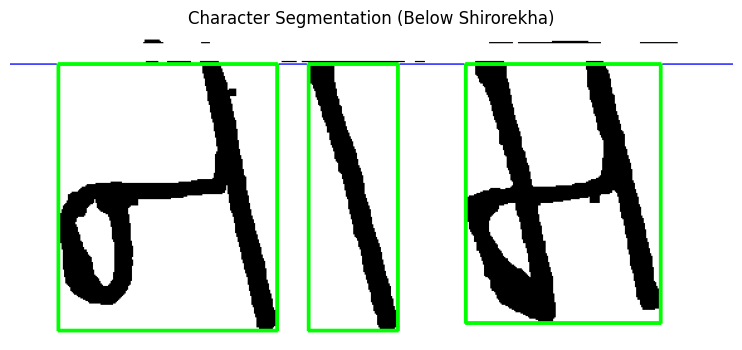


🔠 Characters (below shirorekha) in word 4:


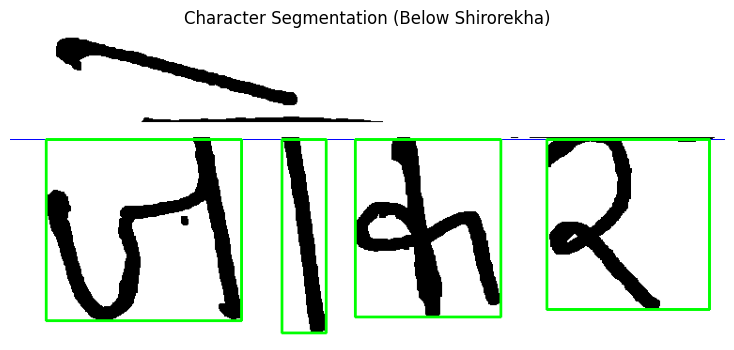

In [205]:
cleaned_word_imgs, shirorekha_positions = remove_shirorekha_from_words(word_imgs=word_imgs, show_steps=False)

for i, (word_img, shiro_pos) in enumerate(zip(cleaned_word_imgs, shirorekha_positions)):
    if shiro_pos is None:
        continue
    print(f"\n🔠 Characters (below shirorekha) in word {i+1}:")
    chars, y_line, boxes = segment_characters_below_shirorekha(word_img, shirorekha_y_range=shiro_pos, show_steps=True)


In [206]:
def preprocess_image_enhanced(image):
    # If it's a color image, convert to grayscale
    if len(image.shape) == 3 and image.shape[2] == 3:
        image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Resize to 32x32
    img = cv2.resize(image, (32, 32), interpolation=cv2.INTER_AREA)

    # Invert colors
    img = cv2.bitwise_not(img)

    # Normalize to [0, 1] file k liyye
    img = img.astype('float32') / 255.0

    # Expand dims: shape (1, 32, 32, 1) for model input
    img = np.expand_dims(img, axis=(0, -1))

    return img

In [207]:
from tensorflow.keras.models import load_model
import joblib

# Load character CNN
char_model = load_model("characters.keras")

# Load label encoder
char_le = joblib.load("character_label_encoder.pkl")

print("✅ Character model loaded")
print("Classes:", char_le.classes_)


✅ Character model loaded
Classes: ['CHAR_A' 'CHAR_BA' 'CHAR_BHA' 'CHAR_CA' 'CHAR_CHA' 'CHAR_DA' 'CHAR_DDA'
 'CHAR_DDHA' 'CHAR_DHA' 'CHAR_E' 'CHAR_GA' 'CHAR_GHA' 'CHAR_GYA' 'CHAR_HA'
 'CHAR_I' 'CHAR_JA' 'CHAR_JHA' 'CHAR_KA' 'CHAR_KHA' 'CHAR_KSHA' 'CHAR_LA'
 'CHAR_MA' 'CHAR_NA' 'CHAR_NGA' 'CHAR_NNA' 'CHAR_NYA' 'CHAR_PA' 'CHAR_PHA'
 'CHAR_RA' 'CHAR_SA' 'CHAR_SHA' 'CHAR_SSA' 'CHAR_TA' 'CHAR_THA' 'CHAR_TRA'
 'CHAR_TTA' 'CHAR_TTHA' 'CHAR_U' 'CHAR_UU' 'CHAR_VA' 'CHAR_YA' 'MATRA_AA']


In [208]:
RENDER_MAP_CHAR = {
    "CHAR_KA": "क", "CHAR_KHA": "ख", "CHAR_GA": "ग", "CHAR_GHA": "घ", "CHAR_NGA": "ङ",
    "CHAR_CA": "च", "CHAR_CHA": "छ", "CHAR_JA": "ज", "CHAR_JHA": "झ", "CHAR_NYA": "ञ",
    "CHAR_TTA": "ट", "CHAR_TTHA": "ठ", "CHAR_DDA": "ड", "CHAR_DDHA": "ढ", "CHAR_NNA": "ण",
    "CHAR_TA": "त", "CHAR_THA": "थ", "CHAR_DA": "द", "CHAR_DHA": "ध", "CHAR_NA": "न",
    "CHAR_PA": "प", "CHAR_PHA": "फ", "CHAR_BA": "ब", "CHAR_BHA": "भ", "CHAR_MA": "म",
    "CHAR_YA": "य", "CHAR_RA": "र", "CHAR_LA": "ल", "CHAR_VA": "व",
    "CHAR_SHA": "श", "CHAR_SSA": "ष", "CHAR_SA": "स", "CHAR_HA": "ह",
    "CHAR_KSHA": "क्ष", "CHAR_TRA": "त्र", "CHAR_GYA": "ज्ञ",
    "CHAR_A": "अ", "CHAR_I": "इ", "CHAR_U": "उ", "CHAR_UU": "ऊ", "CHAR_E": "ए",
    "MATRA_AA": "ा",
}


In [209]:
def prepare_character_for_model(crop, target_size=(32, 32)):
    # Grayscale
    if len(crop.shape) == 3:
        gray = cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY)
    else:
        gray = crop.copy()

    # Invert (white foreground on black)
    inverted = cv2.bitwise_not(gray)

    # Resize
    resized = cv2.resize(inverted, target_size, interpolation=cv2.INTER_AREA)

    # Normalize
    norm = resized.astype("float32") / 255.0

    # Add batch + channel dims
    norm = np.expand_dims(norm, axis=(0, -1))
    return norm


In [210]:
def is_aa_matra(crop, bbox, word_height):
    """
    Geometric detection of aa-matra (ा)
    """
    x, y, w, h, _ = bbox

    # Tall & thin vertical stroke
    if h > 0.45 * word_height and w < 0.4 * h:
        return True

    # Strong right-side attachment
    if h > 0.5 * word_height and w < 0.25 * word_height:
        return True

    return False


In [211]:
def predict_single_character(crop, bbox, word_height, conf_threshold=0.45):

    is_aa = is_aa_matra(crop, bbox, word_height)
    print("AA override:", is_aa)

    if is_aa:
        return {
            "class_id": "MATRA_AA",
            "char": "ा",
            "confidence": 1.0,
            "bbox": bbox
        }

    inp = prepare_character_for_model(crop)
    probs = char_model.predict(inp, verbose=0)[0]
    idx = np.argmax(probs)
    conf = probs[idx]

    if conf < conf_threshold:
        return None

    cls = char_le.inverse_transform([idx])[0]

    return {
        "class_id": cls,
        "char": RENDER_MAP_CHAR[cls],
        "confidence": float(conf),
        "bbox": bbox
    }


In [212]:
def predict_characters_for_word(word_img, shiro_pos, debug=False):
    """
    Returns: list of character prediction dicts
    """
    char_imgs, _, char_boxes = segment_characters_below_shirorekha(
        word_img,
        shirorekha_y_range=shiro_pos,
        show_steps=debug
    )

    predictions = []

    for crop, bbox in zip(char_imgs, char_boxes):
        pred = predict_single_character(
    crop,
    bbox,
    word_img.shape[0]   # <-- pass word height
)

        if pred is not None:
            predictions.append(pred)

    return predictions



🔠 Word 1: character predictions


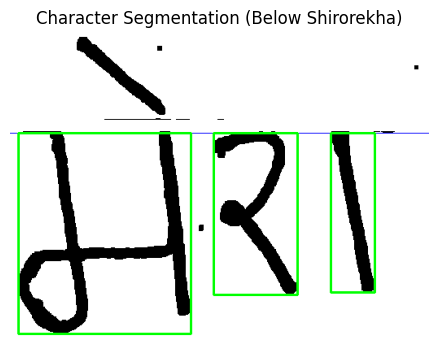

AA override: False
AA override: False
AA override: True
  Char: म | Class: CHAR_MA | Conf: 0.9888 | x: 10
  Char: र | Class: CHAR_RA | Conf: 1.0000 | x: 250
  Char: ा | Class: MATRA_AA | Conf: 1.0000 | x: 394

🔠 Word 2: character predictions


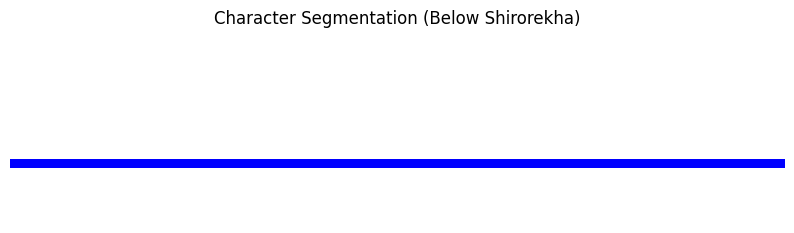


🔠 Word 3: character predictions


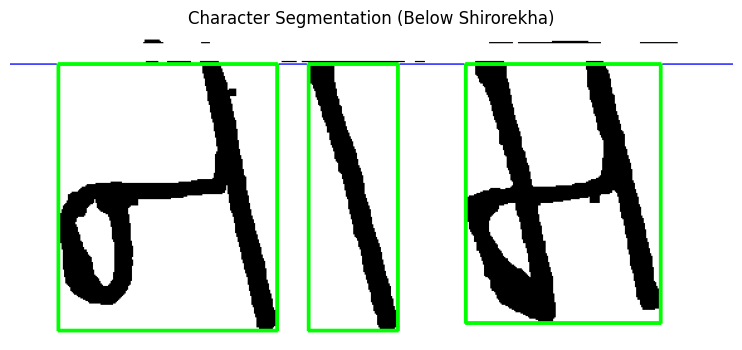

AA override: False
AA override: True
AA override: False
  Char: न | Class: CHAR_NA | Conf: 0.9962 | x: 38
  Char: ा | Class: MATRA_AA | Conf: 1.0000 | x: 237
  Char: म | Class: CHAR_MA | Conf: 0.9912 | x: 362

🔠 Word 4: character predictions


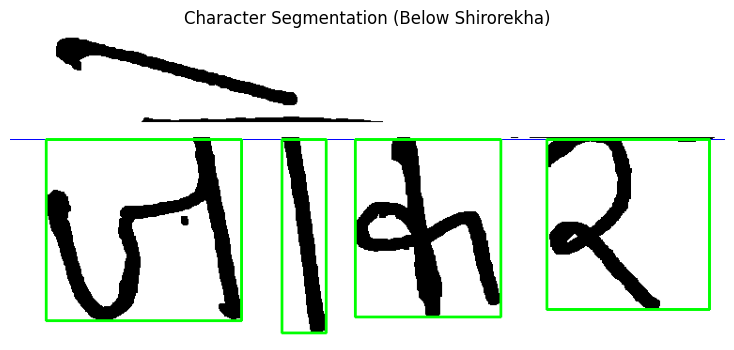

AA override: False
AA override: True
AA override: False
AA override: False
  Char: ज | Class: CHAR_JA | Conf: 0.9987 | x: 38
  Char: ा | Class: MATRA_AA | Conf: 1.0000 | x: 289
  Char: क | Class: CHAR_KA | Conf: 0.9992 | x: 367
  Char: र | Class: CHAR_RA | Conf: 0.9999 | x: 571


In [213]:
for i, (word_img, shiro_pos) in enumerate(zip(cleaned_word_imgs, shirorekha_positions)):
    if shiro_pos is None:
        continue

    print(f"\n🔠 Word {i+1}: character predictions")

    char_preds = predict_characters_for_word(
        word_img,
        shiro_pos,
        debug=True
    )

    for c in char_preds:
        print(
            f"  Char: {c['char']} | "
            f"Class: {c['class_id']} | "
            f"Conf: {c['confidence']:.4f} | "
            f"x: {c['bbox'][4]}"
        )


In [214]:
# Matras by Unicode char
UPPER_MATRAS = {"े", "ै", "ो", "ौ"}
LOWER_MATRAS = {"ु", "ू"}
VERTICAL_MATRAS = {"ि", "ी"}
AA_MATRA = "ा"

# Independent vowels (no matras allowed)
INDEPENDENT_VOWELS = {"अ", "आ", "इ", "ई", "उ", "ऊ", "ए", "ऐ", "ओ", "औ"}


In [215]:
def is_valid_matra_for_base(base_char, matra_char):
    # Independent vowels NEVER take matras
    if base_char in INDEPENDENT_VOWELS:
        return False

    # अ cannot take upper matras (अे, अै invalid)
    if base_char == "अ" and matra_char in UPPER_MATRAS:
        return False

    # No duplicate vowel matras
    if matra_char in {"ा", "ि", "ी", "ु", "ू", "े", "ै", "ो", "ौ"}:
        return True

    return True


In [216]:
def has_vowel_matra(attached):
    for m in attached:
        if m["char"] in {"ा", "ि", "ी", "ु", "ू", "े", "ै", "ो", "ौ"}:
            return True
    return False


In [217]:
MATRA_PRIORITY = {
    "REPHA": 0,      # र् (prefix)
    "MATRA_E": 1,    # े
    "MATRA_AA": 2,   # ा
}


In [218]:
VOWELS = set(["अ", "आ", "इ", "ई", "उ", "ऊ", "ए"])


In [219]:
def horizontal_overlap(box1, box2):
    """
    box = (x, y, w, h, x_center)
    returns overlap width
    """
    x1, _, w1, _, _ = box1
    x2, _, w2, _, _ = box2

    left = max(x1, x2)
    right = min(x1 + w1, x2 + w2)
    return max(0, right - left)


In [220]:
def attach_matras_to_characters(char_preds, matra_preds):
    """
    Attach matras to consonants.
    If overlap fails (e.g. for ा), fall back to nearest previous consonant.
    """

    char_preds = sorted(char_preds, key=lambda c: c["bbox"][4])

    for c in char_preds:
        c["attached_matras"] = []

    for m in matra_preds:
        best_char = None
        best_overlap = 0

        # --- 1. Try overlap-based attachment ---
        for c in char_preds:
            if c["char"] in VOWELS:
                continue

            overlap = horizontal_overlap(c["bbox"], m["bbox"])
            if overlap > best_overlap:
                best_overlap = overlap
                best_char = c

        # --- 2. FALLBACK: nearest previous consonant ---
        if best_char is None:
            mx = m["bbox"][4]  # x_center of matra
            candidates = [
                c for c in char_preds
                if c["char"] not in VOWELS and c["bbox"][4] < mx
            ]
            if candidates:
                best_char = max(candidates, key=lambda c: c["bbox"][4])

        if best_char is not None:
            best_char["attached_matras"].append(m)

    return char_preds


In [221]:
def compose_character(c):
    """
    Correct Unicode composition for Devanagari
    (handles े + ा → ो correctly)
    """

    base = c["char"]
    matras = c.get("attached_matras", [])

    prefix = ""
    suffix_parts = []

    # Sort matras by correct Unicode order
    matras = sorted(
        matras,
        key=lambda m: MATRA_PRIORITY.get(m["class_id"], 99)
    )

    for m in matras:
        if m["class_id"] == "REPHA":
            prefix += "र्"
        else:
            suffix_parts.append(m["char"])

    suffix = "".join(suffix_parts)

    return prefix + base + suffix


In [222]:
def normalize_o_au_matras(word):
    """
    Normalize composite Devanagari matras.
    Ensures:
    े + ा → ो
    ै + ा → ौ
    and removes redundant preceding matras.
    """

    # First collapse combinations
    word = word.replace("ेा", "ो")
    word = word.replace("ैा", "ौ")

    # Then remove leftovers like ेो or ैौ
    word = word.replace("ेो", "ो")
    word = word.replace("ैौ", "ौ")

    return word


In [223]:
def reconstruct_word(char_preds, matra_preds):
    base_chars = []
    extra_matras = []

    for c in char_preds:
        if c["class_id"] == "MATRA_AA":
            extra_matras.append({
                "class_id": "MATRA_AA",
                "char": "ा",
                "bbox": c["bbox"]
            })
        else:
            base_chars.append(c)

    all_matras = matra_preds + extra_matras
    attached_chars = attach_matras_to_characters(base_chars, all_matras)

    word_parts = []
    for c in attached_chars:
        word_parts.append(compose_character(c))

    raw_word = "".join(word_parts)
    return normalize_o_au_matras(raw_word)



In [224]:
def reconstruct_sentence(cleaned_words, shirorekha_positions):
    sentence_words = []

    for word_img, shiro_pos in zip(cleaned_words, shirorekha_positions):
        if shiro_pos is None:
            continue

        # Predict
        char_preds = predict_characters_for_word(word_img, shiro_pos)
        matra_preds = predict_matras_for_word(word_img, shiro_pos)

        # Reconstruct word
        word = reconstruct_word(char_preds, matra_preds)
        sentence_words.append(word)

    return " ".join(sentence_words)


In [228]:
sentence = reconstruct_sentence(cleaned_word_imgs, shirorekha_positions)
# print("\n📝 OCR Output:")
print(sentence)


AA override: False
AA override: False
AA override: True
AA override: False
AA override: True
AA override: False
AA override: False
AA override: True
AA override: False
AA override: False
मेरा  नाम जोकर


मेरा  नाम जोकर